# **Lista de Exercícios - Aula 9**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/aula_09/aula09_exercicios.ipynb)

 - **Professor:** Pedro Alberti 
    - al.pedro.alberti@impatech.edu.br

 - **Monitores:**
   - Bianca Zavadisk
      - al.bianca.abreu@impatech.edu.br
   - Bruno Pereira
      - al.bruno.paula@impatech.edu.br
   - Gustavo Cardoso
      - al.gustavo.cardoso@impatech.edu.br

## **Machine Learning: da Regressão Linear às Árvores de Decisão**

---

### O que tem nesta lista

| # | Exercício | Dificuldade | Dataset |
|---|---|---|---|
| 1 | Regressão logística + avaliação de métricas | 🟢 Fácil | `load_breast_cancer` |
| 2 | Multicolinearidade: escolhendo preditores | 🟡 Médio | `load_diabetes` |
| 3 | Pipeline completo: árvore com profundidade escolhida por cross-validation vs. regressão linear vs. regularização | 🔴 Difícil | `load_diabetes` |

Todos os datasets usados são reais e já vêm com o `scikit-learn` — não é preciso baixar nada.

Resolva cada exercício na célula indicada com `# Seu código aqui`. As soluções completas estão no final do notebook — tente resolver sozinho antes de olhar!


---
## Exercício 1 🟢 — Regressão logística e avaliação de métricas

O dataset `load_breast_cancer` traz medidas de núcleos celulares extraídos de biópsias de mama, com o diagnóstico final: `0 = maligno`, `1 = benigno`. Vamos prever o diagnóstico a partir de uma única medida: `mean radius` (raio médio do núcleo celular).


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.data.join(cancer.target.rename("diagnostico"))

print("0 = maligno, 1 = benigno")
df_cancer[["mean radius", "diagnostico"]].head()


0 = maligno, 1 = benigno


,mean radius,diagnostico
0,17.99,0
1,20.57,0
2,19.69,0
3,11.42,0
4,20.29,0


> 💡 **Duas métricas novas para classificação:**
> - **Acurácia:** fração de previsões corretas, $\dfrac{VP + VN}{VP + VN + FP + FN}$ — vai de 0 (nunca acerta) a 1 (sempre acerta).
> - **Matriz de confusão:** uma tabela 2x2 que mostra, separadamente, os **verdadeiros positivos (VP)**, **verdadeiros negativos (VN)**, **falsos positivos (FP)** e **falsos negativos (FN)** — útil porque a acurácia sozinha pode esconder um modelo que erra sistematicamente uma das classes.

**🎯 Objetivo:**
1. Separe `mean radius` (preditor) e `diagnostico` (target). Divida em treino (70%) e teste (30%) com `train_test_split(..., random_state=42)`.
2. Treine um `LogisticRegression` usando só o treino.
3. Calcule a **acurácia** no teste com `accuracy_score`.
4. Calcule e exiba a **matriz de confusão** no teste com `confusion_matrix`.
5. Em um comentário: o modelo comete mais falsos positivos (dizer "benigno" quando é maligno) ou falsos negativos? Por que isso importa clinicamente?


In [4]:
# Seu código aqui




---
## Exercício 2 🟡 — Multicolinearidade: escolhendo os preditores certos

O `load_diabetes` traz 10 variáveis clínicas de 442 pacientes (idade, IMC, pressão e 6 medidas de sangue `s1` a `s6`) para prever a progressão da doença. Quando várias variáveis estão **correlacionadas entre si**, incluir todas ao mesmo tempo no modelo pode deixar os coeficientes instáveis e difíceis de interpretar — o problema de **multicolinearidade**, mencionado no `Cond. No.` do resumo do `statsmodels` na aula guiada.


In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame

X_diabetes = df_diabetes.drop(columns="target")
y_diabetes = df_diabetes["target"]

X_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


**Parte A — Visualize a correlação entre os preditores**

**🎯 Objetivo:**
1. Calcule a matriz de correlação de `X_diabetes` com `.corr()`.
2. Visualize-a como um mapa de calor (`sns.heatmap` com `annot=True`, ou `plt.imshow` com `plt.colorbar()`).
3. Identifique, em um comentário, pelo menos **um par de variáveis** com correlação forte (por exemplo, acima de 0.7 em módulo).


In [6]:
# Seu código aqui




**Parte B — Escolha de preditores**

Duas variáveis fortemente correlacionadas carregam, em boa parte, a **mesma informação** — incluir as duas raramente ajuda o modelo e pode inflar a incerteza dos coeficientes.

**🎯 Objetivo:**
1. A partir do par (ou pares) identificado na Parte A, escolha **remover uma variável de cada par correlacionado**, mantendo as demais. Salve o resultado em `X_diabetes_reduzido` (um `DataFrame` com menos colunas que `X_diabetes`).
2. Justifique, em um comentário, por que você manteve uma variável do par e descartou a outra (pode ser um critério simples, como manter a de nome/significado clínico mais direto).


In [7]:
# Seu código aqui




**Parte C — Comparando o modelo completo com o modelo reduzido**

**🎯 Objetivo:**
1. Divida `X_diabetes` e `y_diabetes` em treino/teste (`test_size=0.2, random_state=42`) — e separadamente, divida `X_diabetes_reduzido` e `y_diabetes` da mesma forma (**use o mesmo `random_state`**, para comparar os mesmos pacientes nos dois casos).
2. Treine um `LinearRegression` com **todos** os preditores, e outro só com os **preditores reduzidos**.
3. Compare o $R^2$ no teste dos dois modelos.
4. Use `statsmodels` (`sm.OLS` + `sm.add_constant`) para comparar o `Cond. No.` (número de condição) do modelo completo vs. do modelo reduzido — ele diminuiu?
5. Em um comentário: a performance caiu muito ao remover variáveis redundantes? Isso valeu a pena para ganhar estabilidade/interpretabilidade?


In [8]:
# Seu código aqui




---
## Exercício 3 🔴 — Pipeline completo: escolhendo a profundidade da árvore com cross-validation

Na aula guiada, escolhemos a profundidade da árvore olhando o erro no **conjunto de teste**. Isso tem um problema: se usarmos o teste repetidas vezes para tomar decisões sobre o modelo (como escolher um hiperparâmetro), ele deixa de representar dados "nunca vistos" — viramos, sem perceber, a mesma pessoa que "estuda para a prova olhando o gabarito".

A solução é a **validação cruzada (cross-validation)**: dividimos o **treino** em $k$ pedaços ("*folds*"), treinamos $k$ vezes (usando $k-1$ pedaços para treinar e 1 para validar, revezando qual pedaço fica de fora) e tiramos a média do erro. O conjunto de teste continua intocado até a avaliação final.


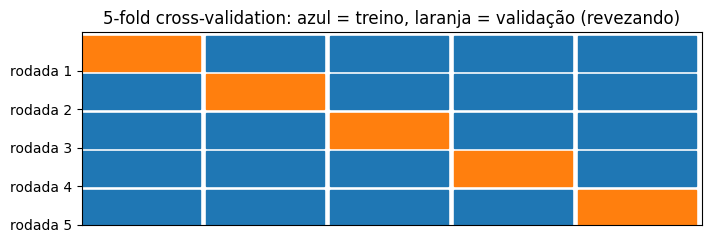

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizando 5-fold cross-validation
k = 5
fig, ax = plt.subplots(figsize=(8, 2.5))
for fold in range(k):
    for bloco in range(k):
        cor = "tab:orange" if bloco == fold else "tab:blue"
        ax.add_patch(plt.Rectangle((bloco, k - fold - 1), 0.95, 0.9, color=cor))
ax.set_xlim(0, k)
ax.set_ylim(0, k)
ax.set_xticks([])
ax.set_yticks(range(k))
ax.set_yticklabels([f"rodada {i+1}" for i in range(k)][::-1])
ax.set_title("5-fold cross-validation: azul = treino, laranja = validação (revezando)")
plt.show()


O `scikit-learn` faz isso com `cross_val_score` (ou `cross_validate`, se quisermos mais detalhes). Vamos usar essa ideia para escolher a melhor profundidade de uma árvore de decisão — **sem nunca tocar no conjunto de teste** até o final.

Vamos continuar com o dataset `load_diabetes` (`X_diabetes`, `y_diabetes`) do Exercício 3.


**Parte A — Separar treino e teste (antes de tudo)**

**🎯 Objetivo:**
1. Divida `X_diabetes` e `y_diabetes` em treino (80%) e teste (20%) com `random_state=42`. Chame de `X_treino`, `X_teste`, `y_treino`, `y_teste`.
2. O conjunto de teste **não deve ser usado em nenhuma etapa até a Parte C** — nem para escolher a profundidade da árvore.


In [10]:
# Seu código aqui




**Parte B — Escolher a profundidade da árvore por cross-validation, com visualização da perda**

**🎯 Objetivo:**
1. Para cada profundidade de 1 a 15, use `cross_val_score` (com `cv=5` e `scoring="neg_mean_squared_error"`) para avaliar um `DecisionTreeRegressor(max_depth=profundidade, random_state=42)` **usando somente `X_treino` e `y_treino`**.
   - Dica: `cross_val_score` retorna o negativo do MSE (por convenção do sklearn, "quanto maior, melhor"); multiplique por `-1` para voltar ao MSE de verdade.
2. Guarde, para cada profundidade, a **média** e o **desvio padrão** do MSE entre os 5 folds.
3. Plote um gráfico de "perda por profundidade": eixo X = profundidade, eixo Y = MSE médio de validação, com uma faixa sombreada (`plt.fill_between`) mostrando ± desvio padrão. Marque a profundidade com menor MSE médio.
4. Guarde essa profundidade em uma variável `melhor_profundidade`.


In [11]:
# Seu código aqui




**Parte C — Agora sim: avaliação final no conjunto de teste**

**🎯 Objetivo:**
1. Treine 3 modelos usando `X_treino`/`y_treino`:
   - Uma `DecisionTreeRegressor(max_depth=melhor_profundidade, random_state=42)`.
   - Uma `LinearRegression`.
   - Uma `Ridge` **ou** `Lasso` (escolha uma, com `alpha=1.0`).
2. Avalie os 3 modelos no `X_teste`/`y_teste`, calculando MSE e $R^2$ de cada um.
3. Monte uma tabela (`pd.DataFrame`) comparando os 3 modelos.


In [12]:
# Seu código aqui




**Parte D — E o vencedor é...**

**🎯 Objetivo:** em um comentário (ou célula de markdown), responda:
1. Qual modelo teve o melhor desempenho no teste?
2. **Por quê?** Pense em: a relação entre os preditores e a progressão da doença parece muito não-linear (o que favoreceria a árvore) ou aproximadamente linear (o que favoreceria a regressão linear/regularizada)? O dataset tem poucos pacientes para uma árvore profunda "aprender" padrões complexos sem overfitar?
3. Isso significa que árvores de decisão são sempre a melhor escolha? Por quê (não)?

> 💡 Não existe uma resposta "certa" universal aqui — o objetivo é que você **justifique sua leitura dos números**, e não apenas escolha o maior $R^2$ sem entender o porquê.


In [13]:
# Seu código aqui (comentário com sua conclusão, ou célula de markdown)




---
## ✅ Soluções

Confira abaixo apenas **depois** de tentar resolver. Existe mais de uma forma correta de resolver — se a sua solução for diferente, mas bem justificada, ótimo!


### Solução — Exercício 1

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.data.join(cancer.target.rename("diagnostico"))

X_cancer = df_cancer[["mean radius"]]
y_cancer = df_cancer["diagnostico"]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cancer, y_cancer, test_size=0.3, random_state=42)

modelo_cancer = LogisticRegression()
modelo_cancer.fit(X_tr_c, y_tr_c)

previsoes_c = modelo_cancer.predict(X_te_c)
acuracia = accuracy_score(y_te_c, previsoes_c)
matriz = confusion_matrix(y_te_c, previsoes_c)

print(f"Acurácia no teste: {acuracia:.3f}")
print("Matriz de confusão (linhas = real, colunas = previsto), ordem [maligno, benigno]:")
print(matriz)
# A matriz de confusão mostra se o modelo erra mais para um lado ou outro.
# Clinicamente, um falso negativo (dizer 'benigno' quando é 'maligno') é o erro
# mais grave, pois atrasaria um diagnóstico e tratamento necessários.


Acurácia no teste: 0.912
Matriz de confusão (linhas = real, colunas = previsto), ordem [maligno, benigno]:
[[ 52  11]
 [  4 104]]


### Solução — Exercício 2

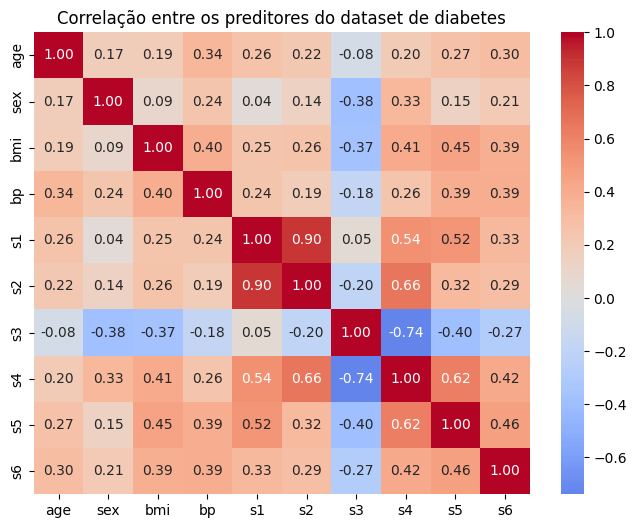

In [16]:
import seaborn as sns
import statsmodels.api as sm

# Parte A
correlacoes = X_diabetes.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre os preditores do dataset de diabetes")
plt.show()
# Pares fortemente correlacionados (|correlação| > 0.7, por exemplo): 's1' e 's2'
# costumam apresentar correlação bem alta (ambas são medidas de colesterol no sangue).


In [17]:
# Parte B
# 's1' e 's2' são fortemente correlacionadas -- vamos manter só 's2' (removendo 's1')
# como critério simples de escolha.
X_diabetes_reduzido = X_diabetes.drop(columns=["s1"])

print("Colunas do modelo completo: ", list(X_diabetes.columns))
print("Colunas do modelo reduzido:", list(X_diabetes_reduzido.columns))


Colunas do modelo completo:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Colunas do modelo reduzido: ['age', 'sex', 'bmi', 'bp', 's2', 's3', 's4', 's5', 's6']


In [18]:
# Parte C
X_tr_full, X_te_full, y_tr_d, y_te_d = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)
X_tr_red, X_te_red, _, _ = train_test_split(X_diabetes_reduzido, y_diabetes, test_size=0.2, random_state=42)

modelo_completo = LinearRegression().fit(X_tr_full, y_tr_d)
modelo_reduzido = LinearRegression().fit(X_tr_red, y_tr_d)

r2_completo = r2_score(y_te_d, modelo_completo.predict(X_te_full))
r2_reduzido = r2_score(y_te_d, modelo_reduzido.predict(X_te_red))
print(f"R² teste -- modelo completo:  {r2_completo:.3f}")
print(f"R² teste -- modelo reduzido: {r2_reduzido:.3f}")

cond_completo = sm.OLS(y_tr_d, sm.add_constant(X_tr_full)).fit().condition_number
cond_reduzido = sm.OLS(y_tr_d, sm.add_constant(X_tr_red)).fit().condition_number
print(f"\nCond. No. -- modelo completo:  {cond_completo:.1f}")
print(f"Cond. No. -- modelo reduzido: {cond_reduzido:.1f}")
# O R² dos dois modelos costuma ficar bem próximo -- a variável removida trazia
# pouca informação nova. Já o número de condição cai no modelo reduzido, indicando
# coeficientes mais estáveis e um modelo mais fácil de interpretar, sem custo
# relevante em desempenho preditivo.


R² teste -- modelo completo:  0.453
R² teste -- modelo reduzido: 0.457

Cond. No. -- modelo completo:  218.7
Cond. No. -- modelo reduzido: 76.6


### Solução — Exercício 3

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

# Parte A
X_treino, X_teste, y_treino, y_teste = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)


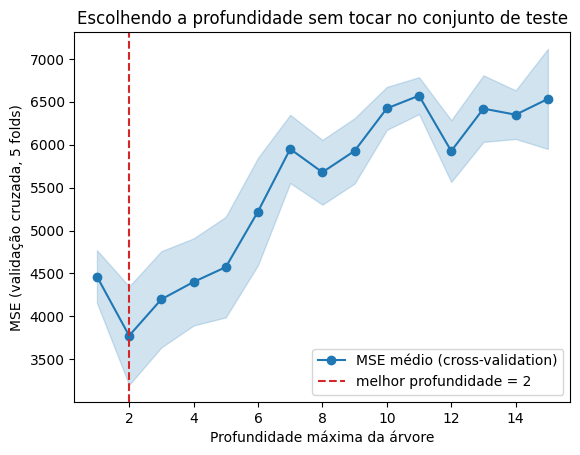

Melhor profundidade encontrada: 2


In [20]:
# Parte B
profundidades = range(1, 16)
mse_medio, mse_desvio = [], []

for prof in profundidades:
    arvore_cv = DecisionTreeRegressor(max_depth=prof, random_state=42)
    scores = cross_val_score(arvore_cv, X_treino, y_treino, cv=5, scoring="neg_mean_squared_error")
    mse_por_fold = -scores  # convertendo de volta para MSE positivo
    mse_medio.append(mse_por_fold.mean())
    mse_desvio.append(mse_por_fold.std())

mse_medio = np.array(mse_medio)
mse_desvio = np.array(mse_desvio)
melhor_profundidade = list(profundidades)[np.argmin(mse_medio)]

plt.plot(profundidades, mse_medio, marker="o", color="tab:blue", label="MSE médio (cross-validation)")
plt.fill_between(profundidades, mse_medio - mse_desvio, mse_medio + mse_desvio, alpha=0.2, color="tab:blue")
plt.axvline(melhor_profundidade, color="tab:red", linestyle="--", label=f"melhor profundidade = {melhor_profundidade}")
plt.xlabel("Profundidade máxima da árvore")
plt.ylabel("MSE (validação cruzada, 5 folds)")
plt.title("Escolhendo a profundidade sem tocar no conjunto de teste")
plt.legend()
plt.show()

print("Melhor profundidade encontrada:", melhor_profundidade)


In [21]:
# Parte C
arvore_final = DecisionTreeRegressor(max_depth=melhor_profundidade, random_state=42).fit(X_treino, y_treino)
linear_final = LinearRegression().fit(X_treino, y_treino)
ridge_final  = Ridge(alpha=1.0).fit(X_treino, y_treino)

resultados_finais = pd.DataFrame({
    "Modelo": [f"Árvore (profundidade {melhor_profundidade})", "Regressão Linear", "Ridge (alpha=1.0)"],
    "MSE teste": [
        mean_squared_error(y_teste, arvore_final.predict(X_teste)),
        mean_squared_error(y_teste, linear_final.predict(X_teste)),
        mean_squared_error(y_teste, ridge_final.predict(X_teste)),
    ],
    "R² teste": [
        r2_score(y_teste, arvore_final.predict(X_teste)),
        r2_score(y_teste, linear_final.predict(X_teste)),
        r2_score(y_teste, ridge_final.predict(X_teste)),
    ],
})
resultados_finais


,Modelo,MSE teste,R² teste
0,Árvore (profundidade 2),3735.499618,0.294943
1,Regressão Linear,2900.193628,0.452603
2,Ridge (alpha=1.0),3077.415939,0.419153


**Parte D — discussão (exemplo de resposta):**

Nos dados de diabetes, a regressão linear e a Ridge costumam empatar ou até superar a árvore de decisão. Isso acontece porque:

- A relação entre as variáveis clínicas e a progressão da doença, neste dataset, é **razoavelmente linear** — não há uma não-linearidade forte como na curva de dose-resposta da aula guiada, que é exatamente o cenário em que árvores brilham.
- O dataset tem **poucos pacientes** (442) para 10 variáveis — uma árvore, mesmo com profundidade escolhida por cross-validation, tem menos dados por "folha" para estimar médias confiáveis, enquanto a regressão linear estima poucos parâmetros (11, incluindo intercepto) de forma mais estável.
- A Ridge, ao penalizar coeficientes grandes, ajuda ainda mais a evitar overfitting num cenário de poucos dados e variáveis correlacionadas (Exercício 3!).

**Conclusão:** árvores de decisão não são "sempre melhores" só por serem mais flexíveis — quando a relação real é aproximadamente linear e os dados são limitados, um modelo mais simples pode generalizar melhor. A escolha do modelo depende dos **dados**, não de qual algoritmo parece mais sofisticado.
